<a href="https://colab.research.google.com/github/myungcho-77/myungcho-77_AdvancedMachineLearning/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iibraries

In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


Dataset

In [2]:
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=url, fname="jena_climate_2009_2016.csv.zip")

extract_dir = os.path.join(os.getcwd(), "jena_climate_data")
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

csv_path = os.path.join(extract_dir, "jena_climate_2009_2016.csv")
print("CSV path:", csv_path)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CSV path: /content/jena_climate_data/jena_climate_2009_2016.csv


Load data

In [3]:
df = pd.read_csv(csv_path)
print(df.shape)
df.head()

(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [4]:
# data inspection
print(df.columns.tolist())
print(df.isnull().sum().sum())

['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
0


Plot Temperature

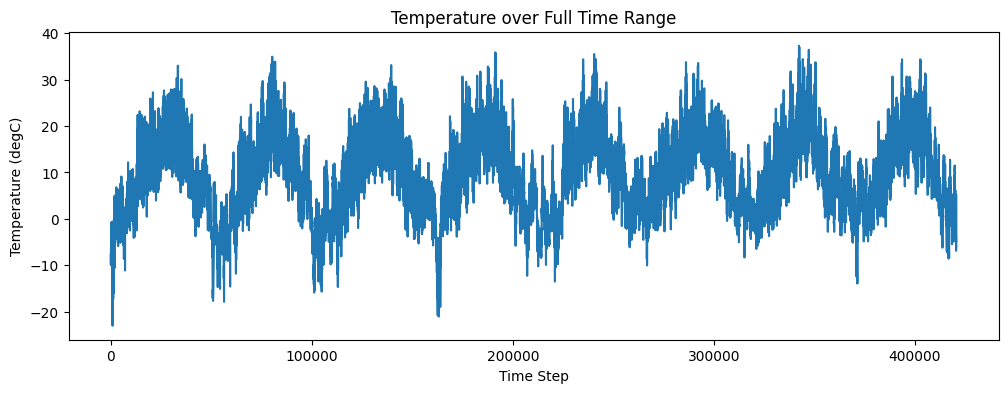

In [5]:
temperature = df["T (degC)"].values

plt.figure(figsize=(12, 4))
plt.plot(range(len(temperature)), temperature)
plt.title("Temperature over Full Time Range")
plt.xlabel("Time Step")
plt.ylabel("Temperature (degC)")
plt.show()

Plot of first 10 days

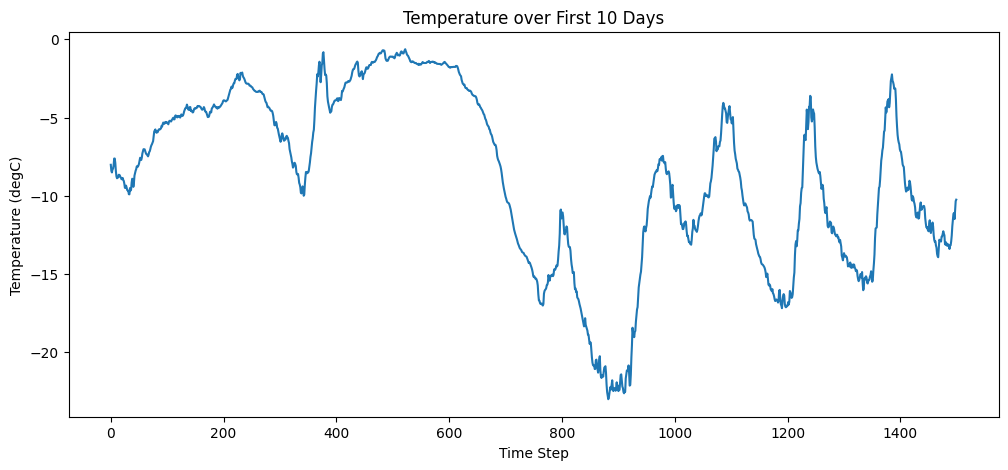

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(range(1500), temperature[:1500])  # 150 observations/day * 10 days
plt.title("Temperature over First 10 Days")
plt.xlabel("Time Step")
plt.ylabel("Temperature (degC)")
plt.show()

Numpy

In [8]:
raw_data = df.iloc[:, 1:].values.astype("float32")  # exclude Date Time
target_index = list(df.columns[1:]).index("T (degC)")

print("raw_data shape:", raw_data.shape)
print("target_index:", target_index)

raw_data shape: (420551, 14)
target_index: 1


Train & Validation & Test

In [9]:
num_samples = len(raw_data)
num_train_samples = int(0.5 * num_samples)
num_val_samples = int(0.25 * num_samples)
num_test_samples = num_samples - num_train_samples - num_val_samples

print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210275
num_val_samples: 105137
num_test_samples: 105139


In [10]:
## Normalize (training data only)
mean = raw_data[:num_train_samples].mean(axis=0)
std = raw_data[:num_train_samples].std(axis=0)

raw_data_norm = (raw_data - mean) / std

Creating Dataset

In [11]:
sampling_rate = 6     # one observation per hour since data is every 10 minutes
sequence_length = 120 # 120 hours = 5 * 24 hours
delay = sampling_rate * (24 + 24)  # predict 24 hours ahead
batch_size = 256

def make_dataset(data, start_index, end_index, shuffle=False):
    inputs = data[start_index:end_index]
    targets = data[start_index + delay:end_index + delay, target_index]

    dataset = keras.utils.timeseries_dataset_from_array(
        data=inputs,
        targets=targets,
        sequence_length=sequence_length,
        sampling_rate=sampling_rate,
        batch_size=batch_size,
        shuffle=shuffle
    )
    return dataset

train_dataset = make_dataset(
    raw_data_norm,
    start_index=0,
    end_index=num_train_samples,
    shuffle=True
)

val_dataset = make_dataset(
    raw_data_norm,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
    shuffle=False
)

test_dataset = make_dataset(
    raw_data_norm,
    start_index=num_train_samples + num_val_samples,
    end_index=len(raw_data_norm) - delay,
    shuffle=False
)

for samples, targets in train_dataset.take(1):
    print("Input shape:", samples.shape)
    print("Target shape:", targets.shape)

Input shape: (256, 120, 14)
Target shape: (256,)


In [12]:
## baseline
def evaluate_naive_method(dataset):
    maes = []
    for samples, targets in dataset:
        # last temperature in the sequence as naive prediction
        preds = samples[:, -1, target_index]
        mae = np.mean(np.abs(preds - targets.numpy()))
        maes.append(mae)
    return np.mean(maes)

naive_val_mae = evaluate_naive_method(val_dataset)
naive_test_mae = evaluate_naive_method(test_dataset)

print("Naive validation MAE:", naive_val_mae)
print("Naive test MAE:", naive_test_mae)

Naive validation MAE: 0.42515785
Naive test MAE: 0.43260473


Helper funtion for training

In [13]:
def compile_and_fit(model, train_data, val_data, epochs=20, model_name="model"):
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=f"{model_name}.keras",
            save_best_only=True,
            monitor="val_mae",
            mode="min"
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_mae",
            patience=5,
            mode="min",
            restore_best_weights=True
        )
    ]

    model.compile(
        optimizer=keras.optimizers.RMSprop(),
        loss="mse",
        metrics=["mae"]
    )

    history = model.fit(
        train_data,
        epochs=epochs,
        validation_data=val_data,
        callbacks=callbacks
    )
    return history

Helper funtion for plotting

In [14]:
def plot_history(history, title):
    mae = history.history["mae"]
    val_mae = history.history["val_mae"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(mae) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, mae, label="Train MAE")
    plt.plot(epochs, val_mae, label="Validation MAE")
    plt.title(title + " - MAE")
    plt.xlabel("Epochs")
    plt.ylabel("MAE")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

**Model 1: Baseline LSTM**

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,049 (23.63 KB)

 Trainable params: 6,049 (23.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 61ms/step - loss: 0.1672 - mae: 0.3104 - val_loss: 0.1009 - val_mae: 0.2490
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 0.0828 - mae: 0.2231 - val_loss: 0.0865 - val_mae: 0.2308
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 68ms/step - loss: 0.0646 - mae: 0.1965 - val_loss: 0.0631 - val_mae: 0.1930
Epoch 4/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 0.0509 - mae: 0.1747 - val_loss: 0.0613 - val_mae: 0.1968
Epoch 5/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 0.0418 - mae: 0.1579 - val_loss: 0.0421 - val_mae: 0.1564
Epoch 6/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 0.0351 - mae: 0.1434 - val_loss: 0.0295 - val_mae: 0.1292
Epoch 7/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 0.0298 - mae: 0.1316 - val_loss: 0.0252 - val_mae: 0.1199
Epoch 8/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 64ms/step - loss: 0.0259 - mae: 0.1224 - val_loss: 0.0305 - val_mae: 0.1316
Epoch 9/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 

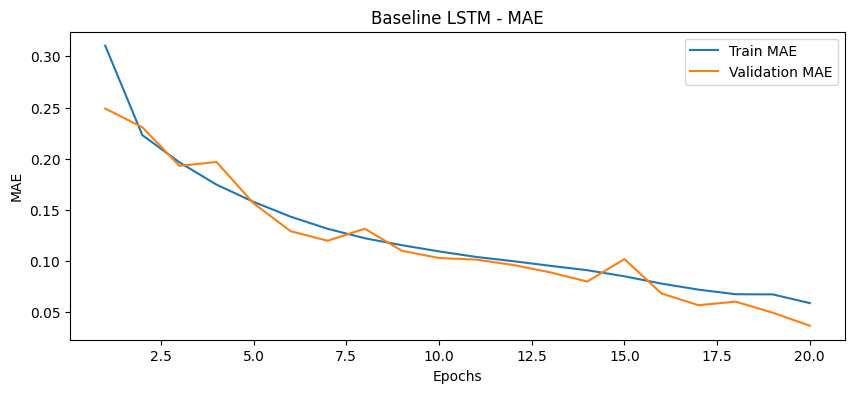

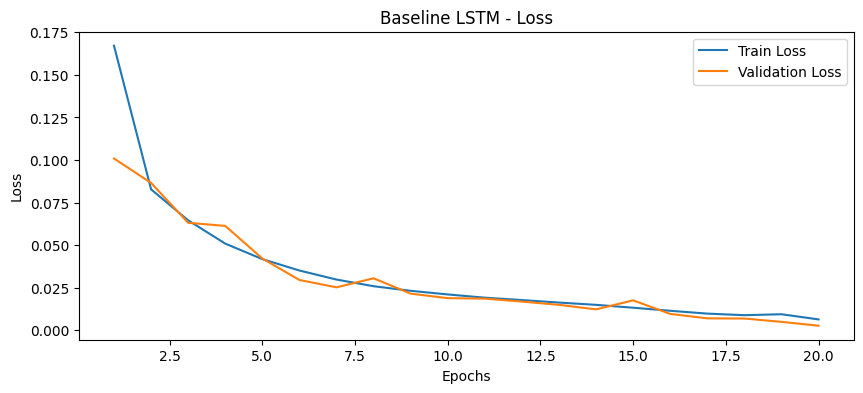

In [15]:
# Build baseline LSTM
inputs = keras.Input(shape=(sequence_length, raw_data_norm.shape[-1]))
x = layers.LSTM(32)(inputs)
outputs = layers.Dense(1)(x)

model_lstm = keras.Model(inputs, outputs)
model_lstm.summary()

# Train baseline LSTM
history_lstm = compile_and_fit(
    model_lstm,
    train_dataset,
    val_dataset,
    epochs=20,
    model_name="baseline_lstm"
)

# Plot baseline LSTM
plot_history(history_lstm, "Baseline LSTM")

**Model 2: LSTM with dropout + recurrent dropout**

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,049 (23.63 KB)

 Trainable params: 6,049 (23.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 324s 391ms/step - loss: 0.2561 - mae: 0.3927 - val_loss: 0.1367 - val_mae: 0.2886
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 321s 392ms/step - loss: 0.1507 - mae: 0.3027 - val_loss: 0.1005 - val_mae: 0.2488
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 325s 397ms/step - loss: 0.1168 - mae: 0.2662 - val_loss: 0.0809 - val_mae: 0.2203
Epoch 4/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 323s 394ms/step - loss: 0.1045 - mae: 0.2520 - val_loss: 0.0731 - val_mae: 0.2077
Epoch 5/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 326s 397ms/step - loss: 0.0982 - mae: 0.2440 - val_loss: 0.0762 - val_mae: 0.2116
Epoch 6/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 324s 396ms/step - loss: 0.0933 - mae: 0.2378 - val_loss: 0.0718 - val_mae: 0.2057
Epoch 7/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 320s 391ms/step - loss: 0.0898 - mae: 0.2332 - val_loss: 0.0689 - val_mae: 0.2033
Epoch 8/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 322s 393ms/step - loss: 0.0870 - mae: 0.2294 - val_loss: 0.0644 - val_mae: 0.1941
Epoch 9/20
819/819 ━━━━━

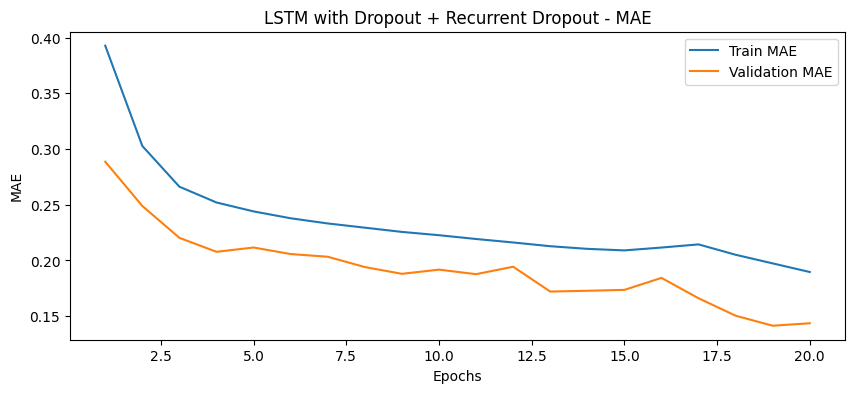

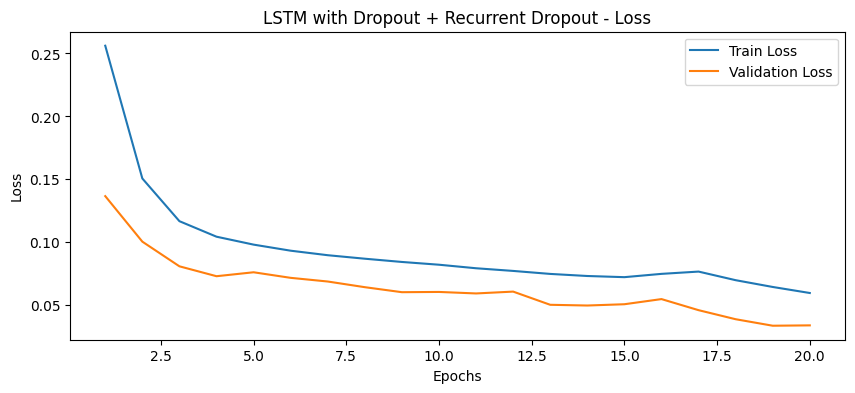

In [16]:
# Build regularized LSTM
inputs = keras.Input(shape=(sequence_length, raw_data_norm.shape[-1]))
x = layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2)(inputs)
outputs = layers.Dense(1)(x)

model_lstm_dropout = keras.Model(inputs, outputs)
model_lstm_dropout.summary()

# Train regularized LSTM
history_lstm_dropout = compile_and_fit(
    model_lstm_dropout,
    train_dataset,
    val_dataset,
    epochs=20,
    model_name="lstm_dropout"
)

# Plot regularized LSTM
plot_history(history_lstm_dropout, "LSTM with Dropout + Recurrent Dropout")


**Model 3: Stacked GRU**

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 120, 32)        │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,977 (42.88 KB)

 Trainable params: 10,977 (42.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - loss: 0.1881 - mae: 0.3326 - val_loss: 0.0975 - val_mae: 0.2486
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - loss: 0.0832 - mae: 0.2250 - val_loss: 0.0729 - val_mae: 0.2114
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 0.0598 - mae: 0.1894 - val_loss: 0.0528 - val_mae: 0.1765
Epoch 4/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 0.0395 - mae: 0.1542 - val_loss: 0.0302 - val_mae: 0.1331
Epoch 5/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 0.0267 - mae: 0.1262 - val_loss: 0.0274 - val_mae: 0.1298
Epoch 6/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 0.0186 - mae: 0.1049 - val_loss: 0.0099 - val_mae: 0.0730
Epoch 7/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 0.0131 - mae: 0.0876 - val_loss: 0.0095 - val_mae: 0.0724
Epoch 8/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 68ms/step - loss: 0.0098 - mae: 0.0741 - val_loss: 0.0042 - val_mae: 0.0475
Epoch 9/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 

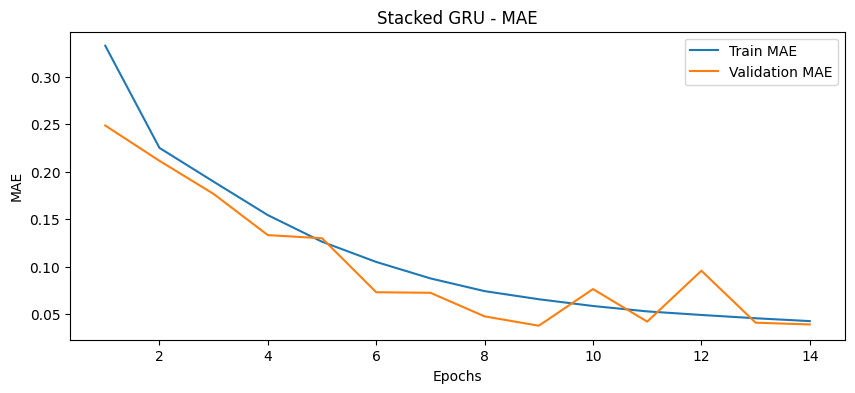

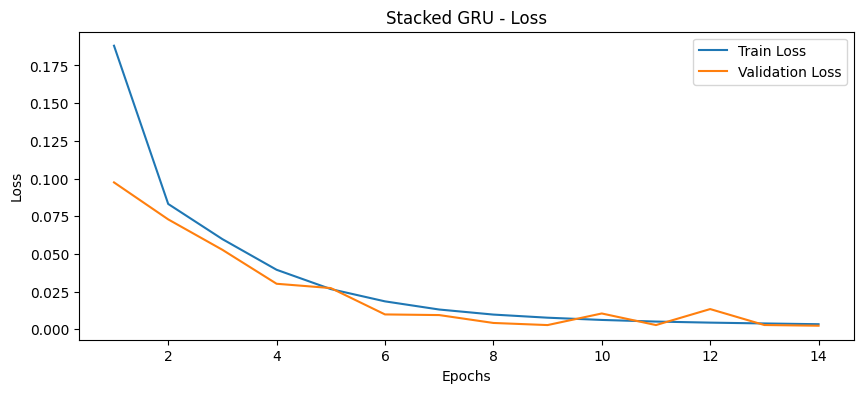

In [17]:
# Build stacked GRU
inputs = keras.Input(shape=(sequence_length, raw_data_norm.shape[-1]))
x = layers.GRU(32, return_sequences=True)(inputs)
x = layers.GRU(32)(x)
outputs = layers.Dense(1)(x)

model_stacked_gru = keras.Model(inputs, outputs)
model_stacked_gru.summary()

# Train stacked GRU
history_stacked_gru = compile_and_fit(
    model_stacked_gru,
    train_dataset,
    val_dataset,
    epochs=20,
    model_name="stacked_gru"
)

# Plot stacked GRU
plot_history(history_stacked_gru, "Stacked GRU")

**Model 4: Conv1D + GRU hybrid**

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 116, 32)        │         2,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 38, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,641 (33.75 KB)

 Trainable params: 8,641 (33.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 53ms/step - loss: 0.1184 - mae: 0.2619 - val_loss: 0.0813 - val_mae: 0.2208
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 0.0527 - mae: 0.1778 - val_loss: 0.0487 - val_mae: 0.1723
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 0.0347 - mae: 0.1445 - val_loss: 0.0274 - val_mae: 0.1257
Epoch 4/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 0.0253 - mae: 0.1228 - val_loss: 0.0187 - val_mae: 0.1035
Epoch 5/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 0.0184 - mae: 0.1046 - val_loss: 0.0179 - val_mae: 0.0990
Epoch 6/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 0.0132 - mae: 0.0884 - val_loss: 0.0108 - val_mae: 0.0817
Epoch 7/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 0.0098 - mae: 0.0763 - val_loss: 0.0058 - val_mae: 0.0571
Epoch 8/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 0.0076 - mae: 0.0676 - val_loss: 0.0039 - val_mae: 0.0448
Epoch 9/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 

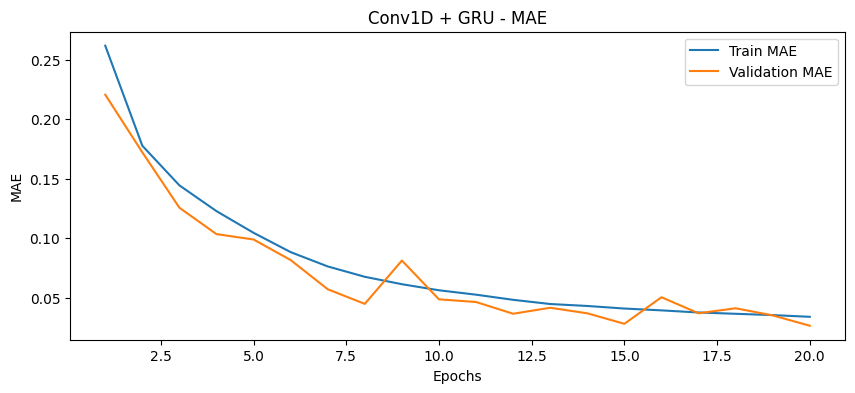

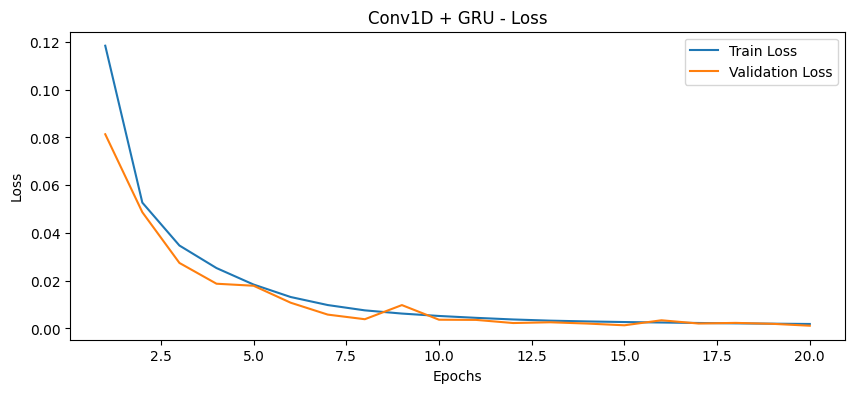

In [18]:
# Build Conv1D + GRU
inputs = keras.Input(shape=(sequence_length, raw_data_norm.shape[-1]))
x = layers.Conv1D(32, 5, activation="relu")(inputs)
x = layers.MaxPooling1D(3)(x)
x = layers.GRU(32)(x)
outputs = layers.Dense(1)(x)

model_conv_gru = keras.Model(inputs, outputs)
model_conv_gru.summary()

# Train Conv1D + GRU
history_conv_gru = compile_and_fit(
    model_conv_gru,
    train_dataset,
    val_dataset,
    epochs=20,
    model_name="conv_gru"
)

# Plot Conv1D + GRU
plot_history(history_conv_gru, "Conv1D + GRU")

**Comparing all models**

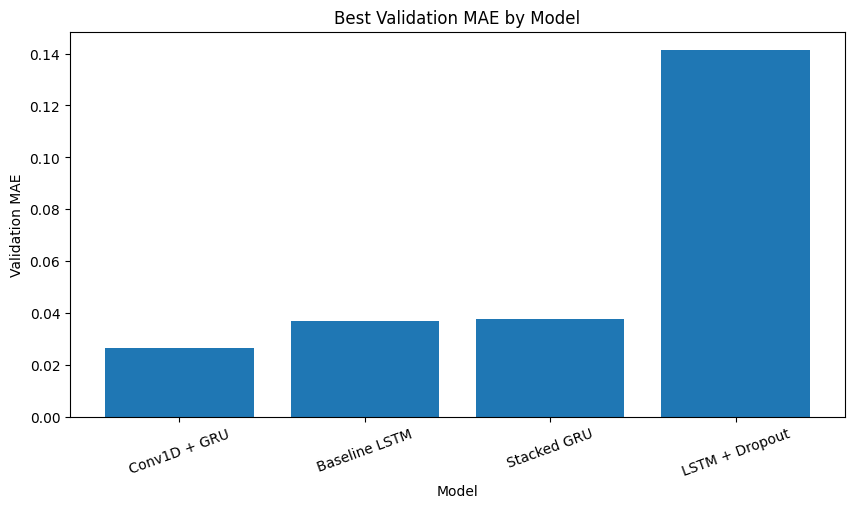

In [19]:
# Collect best validation MAE
results = []

def get_best_val_mae(history, model_name):
    best_val_mae = min(history.history["val_mae"])
    best_epoch = np.argmin(history.history["val_mae"]) + 1
    results.append({
        "Model": model_name,
        "Best Validation MAE": best_val_mae,
        "Best Epoch": best_epoch
    })

get_best_val_mae(history_lstm, "Baseline LSTM")
get_best_val_mae(history_lstm_dropout, "LSTM + Dropout")
get_best_val_mae(history_stacked_gru, "Stacked GRU")
get_best_val_mae(history_conv_gru, "Conv1D + GRU")

results_df = pd.DataFrame(results).sort_values(by="Best Validation MAE")
results_df

# Plot validation MAE comparison
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Best Validation MAE"])
plt.title("Best Validation MAE by Model")
plt.xlabel("Model")
plt.ylabel("Validation MAE")
plt.xticks(rotation=20)
plt.show()

**Evaluate best model on test set**

In [20]:
# Load best model
best_model_name = results_df.iloc[0]["Model"]
print("Best model based on validation MAE:", best_model_name)

model_file_map = {
    "Baseline LSTM": "baseline_lstm.keras",
    "LSTM + Dropout": "lstm_dropout.keras",
    "Stacked GRU": "stacked_gru.keras",
    "Conv1D + GRU": "conv_gru.keras"
}

best_model_path = model_file_map[best_model_name]
best_model = keras.models.load_model(best_model_path)

# Evaluate best model on test data
test_loss, test_mae = best_model.evaluate(test_dataset)
print("Best model test MAE:", test_mae)

# summary table
results_df["Test MAE"] = np.nan
results_df.loc[results_df["Model"] == best_model_name, "Test MAE"] = test_mae
results_df

Best model based on validation MAE: Conv1D + GRU
407/407 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - loss: 0.0043 - mae: 0.0314
Best model test MAE: 0.03137385845184326


,Model,Best Validation MAE,Best Epoch,Test MAE
3,Conv1D + GRU,0.026472,20,0.031374
0,Baseline LSTM,0.036923,20,NaN
2,Stacked GRU,0.037721,9,NaN
1,LSTM + Dropout,0.141405,19,NaN


Save summary

In [21]:
results_df.to_csv("assignment3_model_comparison.csv", index=False)
print("Saved summary table as assignment3_model_comparison.csv")

Saved summary table as assignment3_model_comparison.csv
